# 09 — Genetic Programming v0: DEAP · M1Y WFO · Long+Short · 1h BTC · Realistic Fees

| Design dimension | Choice |
|---|---|
| **Algorithm** | DEAP symbolic GP (tree-based) |
| **Feature diet** | 12 stationary oscillators, distinct from LGBM/DRL/TCN |
| **WFO scheme** | M1Y sliding (8 760h train, 720h step, 12h embargo) |
| **AFML Ch. 2** | Bounded oscillators only — no raw price levels |
| **AFML Ch. 7** | Last 12 bars purged from fitness evaluation each fold |
| **AFML Ch. 14** | Parsimony penalty: Fitness = Sharpe − α × n\_nodes |
| **Output** | Discrete actions {−1, 0, +1} — Short / Flat / Long |
| **Fee model** | 0.05% taker on SL/timeout exits · 0% maker on TP · +0.00077%/h funding on shorts |

This notebook benchmarks `GPTradingAgent` independently before plugging it into `08_meta_learning_v0`.

In [1]:
# Cell 1 — Imports, constants, plot style
import calendar
import json
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from hmats.agents.gp_agent import GP_FEATURES, GPTradingAgent
from hmats.viz.plots import plot_equity_drawdown, save_fig

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO / OOS config (mirrors LGBM v12) ──────────────────────────────────────
OOS_START      = pd.Timestamp('2024-01-01')
TRAIN_WINDOW_H = 8760
STEP_SIZE      = 720

# GP hyperparameters
POP_SIZE    = 300
GENERATIONS = 30
PARSIMONY   = 0.01   # α — penalises n_nodes

# Fee model
TAKER_FEE = 0.0005
FUNDING_H = 0.0000077

print(f'GP features : {len(GP_FEATURES)}')
print(f'OOS start   : {OOS_START.date()}')
print(f'Population  : {POP_SIZE}  Generations: {GENERATIONS}  α={PARSIMONY}')
print('Imports OK')

GP features : 12
OOS start   : 2024-01-01
Population  : 300  Generations: 30  α=0.01
Imports OK


In [2]:
# Cell 2 — Repo root, paths, artifact dir
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
ARTS_DIR = REPO_DIR / 'artifacts' / '09_gp_omni_0fee_v0'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts → {ARTS_DIR}')

Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/09_gp_omni_0fee_v0


In [3]:
# Cell 3 — Data loading
# GP uses only V1 features — all 12 GP_FEATURES are in the V1 parquet.
print('Loading V1 features...')
v1 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1.index = v1.index.tz_localize(None) if v1.index.tz else v1.index

_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)

merged = v1.copy()
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

present = [f for f in GP_FEATURES if f in merged.columns]
missing = [f for f in GP_FEATURES if f not in merged.columns]
print(f'GP features present: {len(present)} / {len(GP_FEATURES)}')
if missing: print(f'  Missing (will be 0): {missing}')

oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars: {len(merged):,}  |  OOS bars: {len(oos_df):,}')

# Verify stationarity (sanity check: no raw price columns in GP diet)
price_cols = [f for f in GP_FEATURES if f in ('close', 'open', 'high', 'low', 'volume')]
assert not price_cols, f'AFML Ch.2 violation: raw price columns in GP diet: {price_cols}'
print('\nAFML Ch. 2 check PASSED — no raw price levels in feature diet')
print('\nGP feature diet:')
for f in GP_FEATURES:
    tag = '✓' if f in merged.columns else '✗ MISSING'
    print(f'  {tag}  {f}')

Loading V1 features...
GP features present: 12 / 12
Total bars: 74,366  |  OOS bars: 20,785

AFML Ch. 2 check PASSED — no raw price levels in feature diet

GP feature diet:
  ✓  rsi_7
  ✓  rsi_21
  ✓  stoch_k_21
  ✓  bb_position_50
  ✓  bb_squeeze_20
  ✓  mfi_14
  ✓  williams_r
  ✓  cmf_20
  ✓  macd_hist_12_26
  ✓  hl_position_24h
  ✓  obv_z_72
  ✓  vol_z_24h


In [4]:
# Cell 4 — PHASE 1: GP WFO signal generation
print('='*60)
print('PHASE 1 — M1Y WFO: Genetic Programming signal generation')
print('='*60)

agent = GPTradingAgent(
    features=[f for f in GP_FEATURES if f in merged.columns],
    population_size=POP_SIZE,
    generations=GENERATIONS,
    parsimony_coefficient=PARSIMONY,
    train_window_h=TRAIN_WINDOW_H,
    step_size=STEP_SIZE,
)

t0 = time.time()
gp_signals = agent.generate_signals(merged, oos_start=OOS_START, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

# Cache signals for meta-learning notebook
sig_path = ARTS_DIR / 'gp_oos_signals.parquet'
gp_signals.to_frame().to_parquet(sig_path)
print(f'Signals saved → {sig_path}')

# Action distribution
vc = gp_signals.value_counts().sort_index()
for k, v in vc.items():
    name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
    print(f'  {name:5}: {v:5,}  ({v/len(gp_signals)*100:.1f}%)')

PHASE 1 — M1Y WFO: Genetic Programming signal generation
  [gp_v0] fold   1  fitness=+31.8069  nodes=  3  height=1  gen_max=+31.8069
  [gp_v0] fold   2  fitness=+32.8289  nodes= 14  height=5  gen_max=+32.8289
  [gp_v0] fold   3  fitness=+32.1621  nodes=  7  height=2  gen_max=+32.1621
  [gp_v0] fold   4  fitness=+32.5755  nodes= 10  height=3  gen_max=+32.2653
  [gp_v0] fold   5  fitness=+31.3125  nodes= 13  height=4  gen_max=+31.2778
  [gp_v0] fold   6  fitness=+31.1073  nodes=  9  height=3  gen_max=+31.0024
  [gp_v0] fold   7  fitness=+31.8526  nodes= 21  height=8  gen_max=+31.8526
  [gp_v0] fold   8  fitness=+32.3347  nodes= 38  height=7  gen_max=+32.3347
  [gp_v0] fold   9  fitness=+31.2750  nodes= 20  height=5  gen_max=+31.2150
  [gp_v0] fold  10  fitness=+32.0525  nodes= 24  height=5  gen_max=+32.0525
  [gp_v0] fold  11  fitness=+30.7616  nodes=  3  height=1  gen_max=+30.7616
  [gp_v0] fold  12  fitness=+30.8184  nodes=  3  height=1  gen_max=+30.8184
  [gp_v0] fold  13  fitness=+31

In [5]:
# Cell 5 — Evolved rule tree inspection (thesis white-box contrast)
print('='*60)
print('EVOLVED RULE TREES — Walk-Forward Windows')
print('='*60)
print('Each tree is the Hall-of-Fame winner evolved on a 1-year training window.')
print('Parsimony penalty (α=%.3g) forces shorter, more generalisable rules.\n' % PARSIMONY)

# Print trees for OOS folds (oos_start >= 2024-01-01)
oos_folds = [fw for fw in agent.fold_winners
             if fw['oos_start'] >= OOS_START]

for fw in oos_folds:
    print(f"Fold {fw['fold']:>3}  OOS: {fw['oos_start'].date()} → {fw['oos_end'].date()}")
    print(f"  Fitness: {fw['fitness']:+.4f}  (Sharpe − {PARSIMONY} × {fw['n_nodes']} nodes)")
    print(f"  Nodes: {fw['n_nodes']}  Height: {fw['height']}")
    print(f"  Rule: {fw['tree_str']}")
    print()

if not oos_folds:
    print('(Run generate_signals first — fold_winners is empty)')

# Summary stats
if agent.fold_winners:
    all_nodes   = [fw['n_nodes']  for fw in agent.fold_winners]
    all_heights = [fw['height']   for fw in agent.fold_winners]
    all_fitness = [fw['fitness']  for fw in agent.fold_winners]
    print(f'\nAll-folds summary  ({len(agent.fold_winners)} folds):')
    print(f'  n_nodes  — mean: {np.mean(all_nodes):.1f}   range: [{min(all_nodes)}, {max(all_nodes)}]')
    print(f'  height   — mean: {np.mean(all_heights):.1f}  range: [{min(all_heights)}, {max(all_heights)}]')
    print(f'  fitness  — mean: {np.mean(all_fitness):+.4f}  best: {max(all_fitness):+.4f}')

EVOLVED RULE TREES — Walk-Forward Windows
Each tree is the Hall-of-Fame winner evolved on a 1-year training window.
Parsimony penalty (α=0.01) forces shorter, more generalisable rules.

Fold  64  OOS: 2024-01-23 → 2024-02-22
  Fitness: +33.8807  (Sharpe − 0.01 × 22 nodes)
  Nodes: 22  Height: 5
  Rule: Sub(Div(GT(rsi_7, rsi_21), Add(Mul(And(macd_hist_12_26, williams_r), Div(rsi_21, rsi_7)), LT(IfPos(bb_squeeze_20, bb_squeeze_20, obv_z_72), Div(williams_r, williams_r)))), williams_r)

Fold  65  OOS: 2024-02-22 → 2024-03-23
  Fitness: +35.5309  (Sharpe − 0.01 × 16 nodes)
  Nodes: 16  Height: 4
  Rule: Sub(LT(mfi_14, rsi_7), Sub(Or(GT(williams_r, rsi_7), Mul(rsi_7, macd_hist_12_26)), Not(GT(rsi_21, rsi_7))))

Fold  66  OOS: 2024-03-23 → 2024-04-22
  Fitness: +33.6996  (Sharpe − 0.01 × 5 nodes)
  Nodes: 5  Height: 2
  Rule: Div(Sub(rsi_7, rsi_21), rsi_21)

Fold  67  OOS: 2024-04-22 → 2024-05-22
  Fitness: +34.1127  (Sharpe − 0.01 × 5 nodes)
  Nodes: 5  Height: 2
  Rule: Sub(rsi_7, Add(rsi_

In [6]:
# Cell 6 — PHASE 2: Backtest
print('='*60)
print('PHASE 2 — OOS BACKTEST')
print('='*60)

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


def run_gp_backtest(
    actions: np.ndarray,
    close_arr: np.ndarray,
    high_arr: np.ndarray,
    low_arr: np.ndarray,
    atr_arr: np.ndarray,
    with_fees: bool = True,
    sl_mult: float = 2.0,
    tp_mult: float = 3.0,
    min_hold: int = 4,
    max_hold: int = 24,
    cooldown: int = 2,
) -> tuple:
    """GP backtest: ATR-based SL/TP triggered by discrete GP actions."""
    MAKER_FEE  = 0.0000
    SPOT_TAKER = TAKER_FEE
    FUT_TAKER  = TAKER_FEE
    MIN_SL     = 0.010

    n = len(close_arr)
    eq = np.ones(n); cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = entry_fee = funding = 0.0
    pos_eq = 1.0; hold_cnt = cd_cnt = 0

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]
        act = int(actions[i])

        if in_pos:
            hold_cnt += 1
            if direction == 'short': funding += FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == 'long'
                              else 1 + (entry_px - px) / entry_px)
            exited = False; exit_px = 0.; reason = ''; exit_fee = 0.

            if hold_cnt >= min_hold:
                if direction == 'long':
                    if   lo <= sl_px:                exit_px=sl_px;  exited=True; reason='sl';    exit_fee=SPOT_TAKER if with_fees else 0.
                    elif hi >= tp_px:                exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, -1):
                                                     exit_px=px;     exited=True; reason='close'; exit_fee=SPOT_TAKER if with_fees else 0.
                else:
                    if   hi >= sl_px:                exit_px=sl_px;  exited=True; reason='sl';    exit_fee=FUT_TAKER  if with_fees else 0.
                    elif lo <= tp_px:                exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, 1):
                                                     exit_px=px;     exited=True; reason='close'; exit_fee=FUT_TAKER  if with_fees else 0.

            if exited:
                gross = ((exit_px-entry_px)/entry_px if direction=='long'
                         else (entry_px-exit_px)/entry_px)
                net = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur = pos_eq*(1.+net); eq[i] = cur
                trades.append({'direction': direction, 'reason': reason,
                               'gross': gross, 'net': net, 'hold': hold_cnt})
                in_pos = False; cd_cnt = cooldown; funding = 0.
        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur
        elif act != 0 and i+1 < n:
            atr = max(float(atr_arr[i]) if not np.isnan(atr_arr[i]) else MIN_SL, MIN_SL)
            direction = 'long' if act == 1 else 'short'
            entry_px = px
            entry_fee = SPOT_TAKER if with_fees else 0.
            if direction == 'long':
                sl_px = px*(1 - sl_mult*atr); tp_px = px*(1 + tp_mult*atr)
            else:
                sl_px = px*(1 + sl_mult*atr); tp_px = px*(1 - tp_mult*atr)
            in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.
            eq[i] = cur
        else:
            eq[i] = cur

    if in_pos:
        px = close_arr[-1]
        gross = ((px-entry_px)/entry_px if direction=='long'
                 else (entry_px-px)/entry_px)
        tf = SPOT_TAKER if direction=='long' else FUT_TAKER
        net = gross - (entry_fee+(tf if with_fees else 0.)) + funding
        cur = pos_eq*(1.+net); eq[-1] = cur

    return eq, trades


_acts  = gp_signals.values
_close = oos_df['close'].values
_high  = oos_df['high'].values
_low   = oos_df['low'].values
_atr   = oos_df['atr_14_pct'].values

eq_fees, tdf_fees_raw = run_gp_backtest(_acts, _close, _high, _low, _atr, with_fees=True)
eq_0fee, tdf_0fee_raw = run_gp_backtest(_acts, _close, _high, _low, _atr, with_fees=False)

def _tdf(raw): return pd.DataFrame(raw) if raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])

tdf_fees = _tdf(tdf_fees_raw)
tdf_0fee = _tdf(tdf_0fee_raw)

print(f'\n{"":22}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─'*75)
for lbl, eq, tdf in [
    ('With fees (primary)', eq_fees, tdf_fees),
    ('Zero-fee (upper)',    eq_0fee, tdf_0fee),
]:
    wr  = (tdf['net']>0).mean()                if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum()) if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum())if len(tdf) else 0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

PHASE 2 — OOS BACKTEST

                         Trades        L/S   WinRate    Return   Sharpe    MaxDD
───────────────────────────────────────────────────────────────────────────
With fees (primary)        2055  1050/1005     32.7%   -87.7%   -2.258  -89.42%
Zero-fee (upper)           2055  1050/1005     37.2%   -10.2%   -0.118  -51.18%


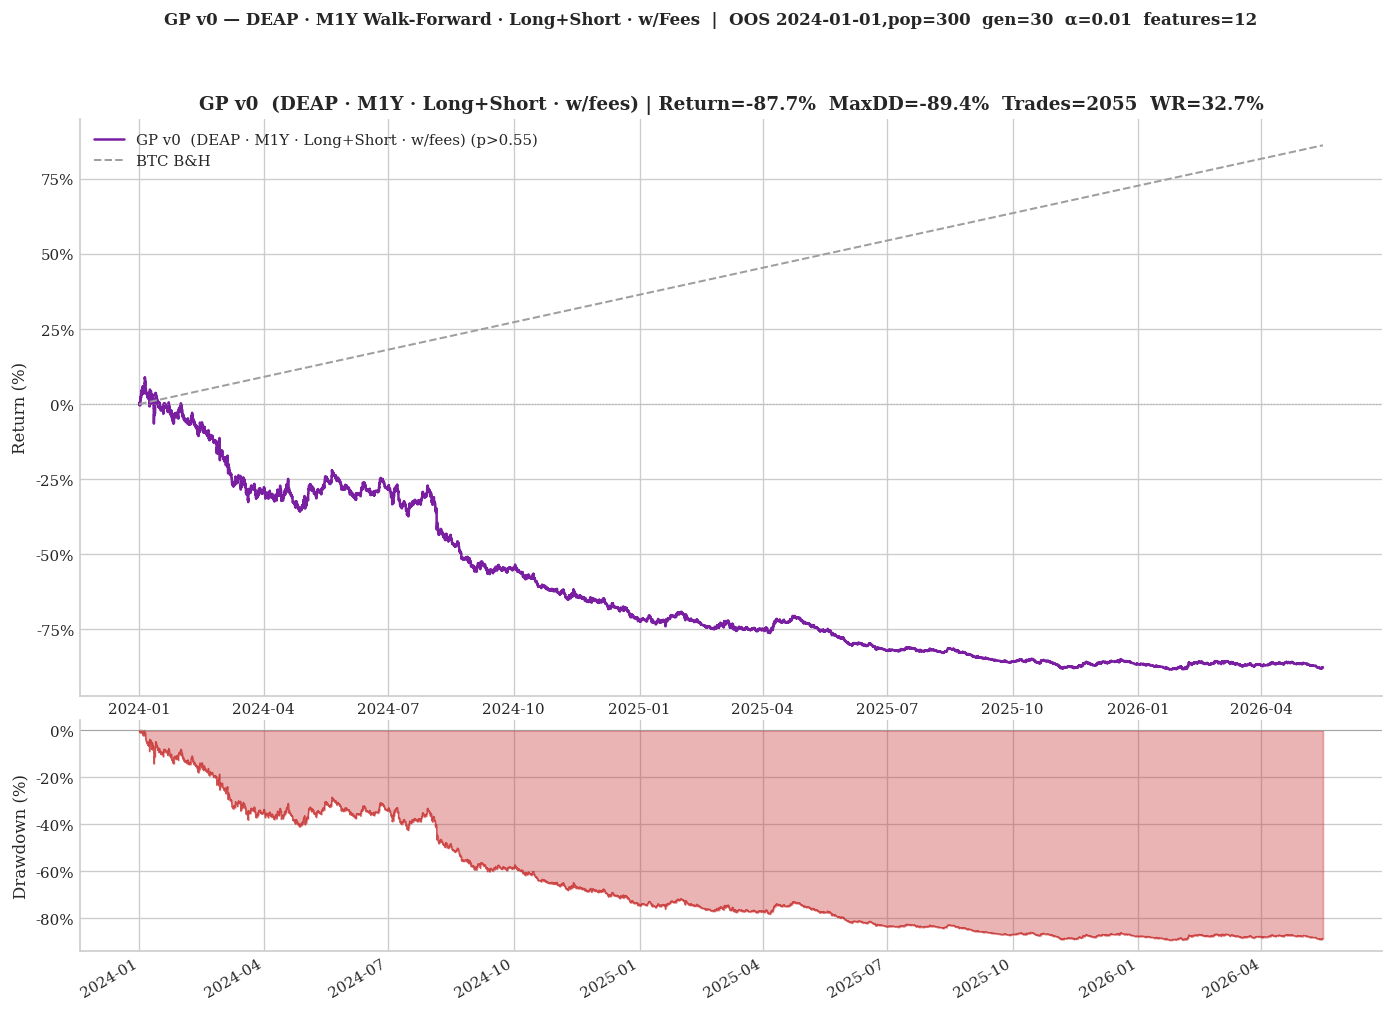

In [8]:
# Cell 7 — Equity / drawdown plot
oos_index = oos_df.index
_oos_end_px   = oos_df['close'].iloc[-1]
_oos_start_px = oos_df['close'].iloc[0]
bh_pct = np.linspace(0., (_oos_end_px / _oos_start_px - 1) * 100, len(oos_index))

fig = plot_equity_drawdown(
    oos_index, eq_fees, tdf_fees,
    bh_pct=bh_pct,
    label='GP v0  (DEAP · M1Y · Long+Short · w/fees)',
    color=PURPLE,
)
fig.suptitle(
    f'GP v0 — DEAP · M1Y Walk-Forward · Long+Short · w/Fees  |  OOS {OOS_START.date()},'
    f'pop={POP_SIZE}  gen={GENERATIONS}  α={PARSIMONY}  features={len(GP_FEATURES)}',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()

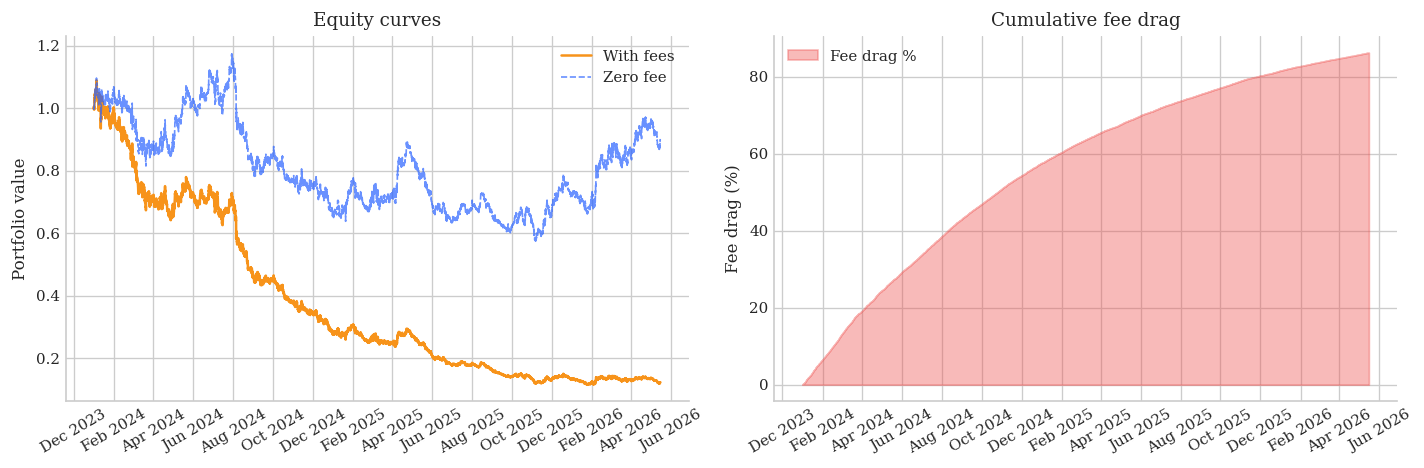

In [9]:
# Cell 8 — Fee comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(oos_index, eq_fees, color=ACCENT, lw=1.5, label='With fees')
ax.plot(oos_index, eq_0fee, color=BLUE,   lw=1.0, ls='--', alpha=0.7, label='Zero fee')
ax.set_title('Equity curves'); ax.set_ylabel('Portfolio value'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
fee_drag = (eq_0fee - eq_fees) / eq_0fee * 100
ax.fill_between(oos_index, 0, fee_drag, color=RED, alpha=0.4, label='Fee drag %')
ax.set_title('Cumulative fee drag'); ax.set_ylabel('Fee drag (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30); ax.legend()

fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()

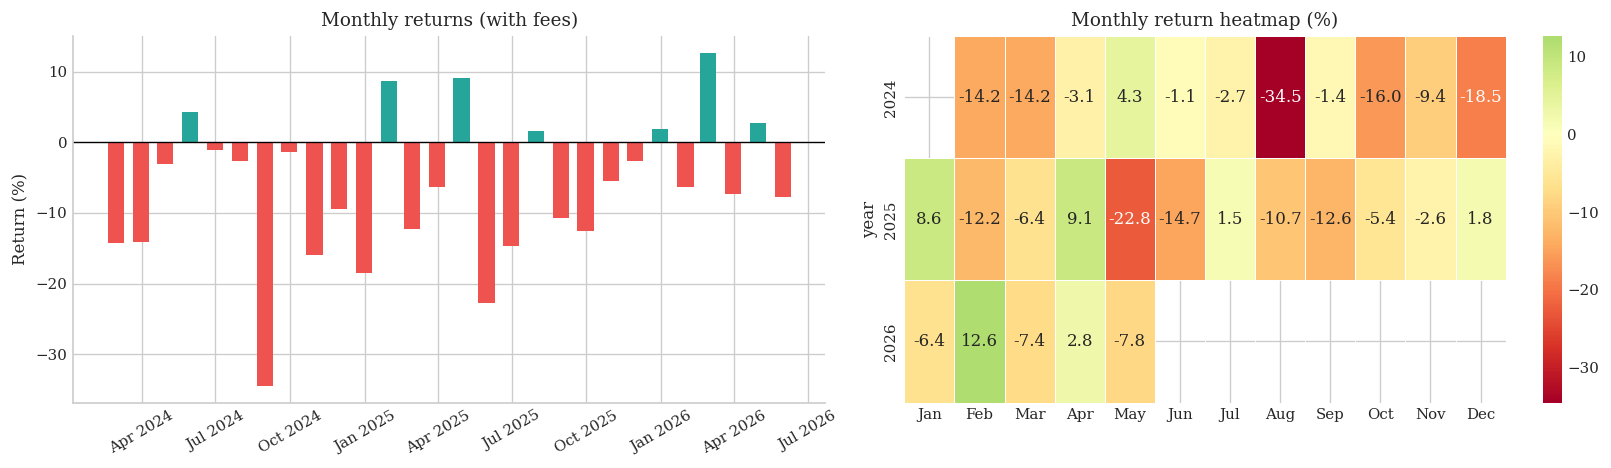

Monthly win rate: 25%
Best month: +12.64%  Worst: -34.48%


In [10]:
# Cell 9 — Monthly return analysis
eq_full_series = pd.Series(eq_fees, index=oos_index)
monthly_ret = eq_full_series.resample('ME').last().pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
colors_bar = [GREEN if r >= 0 else RED for r in monthly_ret]
ax.bar(monthly_ret.index, monthly_ret.values*100, color=colors_bar, width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Monthly returns (with fees)'); ax.set_ylabel('Return (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
pivot_df = monthly_ret.to_frame('ret')
pivot_df['year']  = pivot_df.index.year
pivot_df['month'] = pivot_df.index.month
try:
    heat = pivot_df.pivot(index='year', columns='month', values='ret') * 100
    heat.columns = [calendar.month_abbr[m] for m in heat.columns]
    sns.heatmap(heat, annot=True, fmt='.1f', center=0,
                cmap='RdYlGn', linewidths=0.5, ax=ax)
    ax.set_title('Monthly return heatmap (%)')
except Exception as e:
    ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)

fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

print(f'Monthly win rate: {(monthly_ret > 0).mean():.0%}')
print(f'Best month: {monthly_ret.max():+.2%}  Worst: {monthly_ret.min():+.2%}')

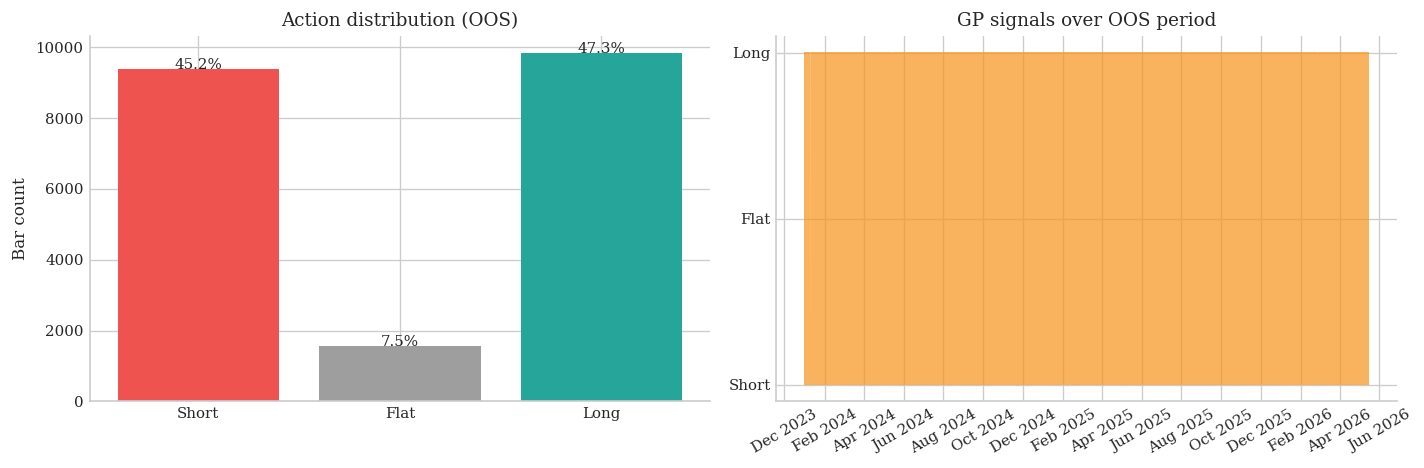

In [11]:
# Cell 10 — Signal / action distribution over OOS period
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
act_names = {-1: 'Short', 0: 'Flat', 1: 'Long'}
vc = gp_signals.value_counts().sort_index()
bar_colors = [RED, GREY, GREEN]
ax.bar([act_names.get(k, str(k)) for k in vc.index], vc.values,
       color=bar_colors[:len(vc)])
ax.set_title('Action distribution (OOS)')
ax.set_ylabel('Bar count')
for i, (k, v) in enumerate(vc.items()):
    ax.text(i, v + 5, f'{v/len(gp_signals)*100:.1f}%', ha='center', fontsize=9)

ax = axes[1]
ax.plot(oos_index, gp_signals.values, color=ACCENT, lw=0.5, alpha=0.7)
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(['Short', 'Flat', 'Long'])
ax.set_title('GP signals over OOS period')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.tight_layout()
save_fig(fig, ARTS_DIR / '04_action_distribution.png')
plt.show()

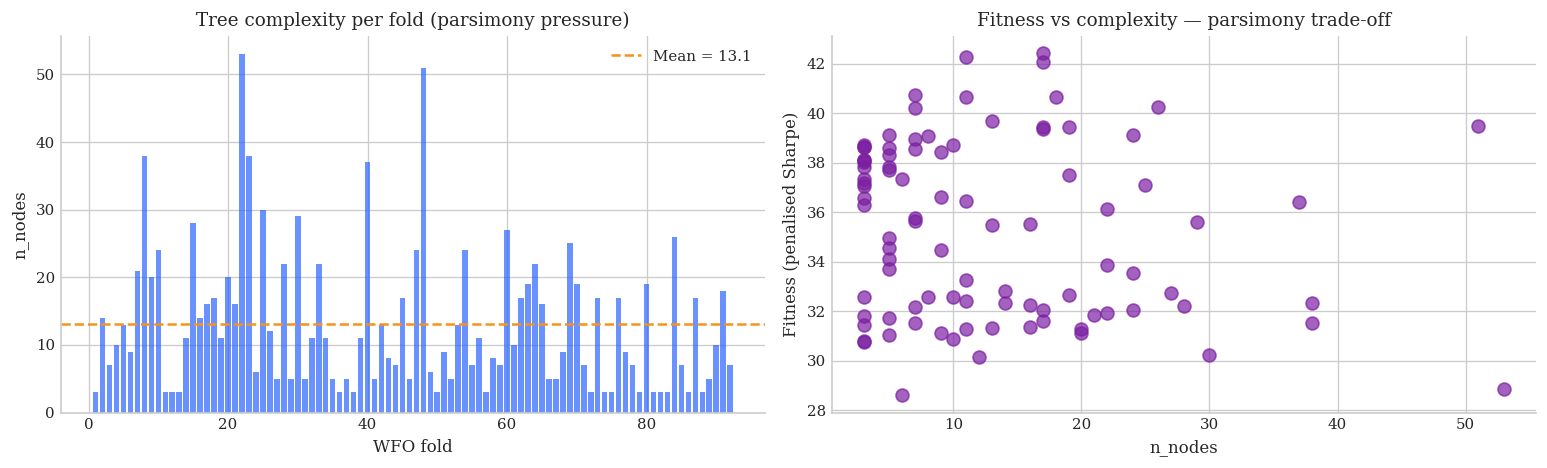

In [12]:
# Cell 11 — Tree complexity across folds (parsimony visualisation)
if agent.fold_winners:
    fold_nums   = [fw['fold']    for fw in agent.fold_winners]
    fold_nodes  = [fw['n_nodes'] for fw in agent.fold_winners]
    fold_fitness= [fw['fitness'] for fw in agent.fold_winners]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.bar(fold_nums, fold_nodes, color=BLUE, alpha=0.7)
    ax.axhline(np.mean(fold_nodes), color=ACCENT, lw=1.5, ls='--',
               label=f'Mean = {np.mean(fold_nodes):.1f}')
    ax.set_xlabel('WFO fold'); ax.set_ylabel('n_nodes')
    ax.set_title('Tree complexity per fold (parsimony pressure)')
    ax.legend()

    ax = axes[1]
    ax.scatter(fold_nodes, fold_fitness, color=PURPLE, alpha=0.7, s=60)
    ax.set_xlabel('n_nodes'); ax.set_ylabel('Fitness (penalised Sharpe)')
    ax.set_title('Fitness vs complexity — parsimony trade-off')

    fig.tight_layout()
    save_fig(fig, ARTS_DIR / '05_tree_complexity.png')
    plt.show()

In [13]:
# Cell 12 — Save results.json
def _bt_metrics(eq, tdf, label):
    wr = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    avg_hold = float(tdf['hold'].mean()) if len(tdf) else 0.
    return {
        'label':       label,
        'n_trades':    len(tdf),
        'n_long':      n_l,
        'n_short':     n_s,
        'win_rate':    round(wr, 4),
        'avg_hold_h':  round(avg_hold, 1),
        'total_return':round(float(eq[-1]-1), 4),
        'sharpe':      round(_sharpe(eq), 4),
        'max_drawdown':round(_maxdd(eq), 4),
    }

results = {
    'agent':        'GPTradingAgent v0',
    'notebook':     '09_gp_omni_0fee_v0',
    'oos_start':    str(OOS_START.date()),
    'oos_end':      str(oos_df.index[-1].date()),
    'oos_bars':     len(oos_df),
    'gp_config': {
        'population_size': POP_SIZE,
        'generations':     GENERATIONS,
        'parsimony_alpha': PARSIMONY,
        'train_window_h':  TRAIN_WINDOW_H,
        'step_size':       STEP_SIZE,
        'n_features':      len(GP_FEATURES),
        'features':        GP_FEATURES,
        'afml_defences':   [
            'Ch.2 feature stationarity — bounded oscillators only',
            'Ch.7 purged fitness — last 12 bars excluded each fold',
            'Ch.14 parsimony pressure — Fitness = Sharpe - α×n_nodes',
        ],
    },
    'backtest_with_fees': _bt_metrics(eq_fees, tdf_fees, 'with_fees'),
    'backtest_zero_fee':  _bt_metrics(eq_0fee, tdf_0fee, 'zero_fee'),
    'fold_winners': [
        {
            'fold':      fw['fold'],
            'oos_start': str(fw['oos_start'].date()),
            'oos_end':   str(fw['oos_end'].date()),
            'n_nodes':   fw['n_nodes'],
            'height':    fw['height'],
            'fitness':   round(fw['fitness'], 4),
            'tree':      fw['tree_str'],
        }
        for fw in agent.fold_winners
        if fw['oos_start'] >= OOS_START
    ],
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as fh:
    json.dump(results, fh, indent=2)
print(f'Saved → {out_path}')

print(f"\n{'='*55}")
print(f"GP v0  OOS {results['oos_start']} → {results['oos_end']}")
print(f"{'='*55}")
m = results['backtest_with_fees']
print(f"Return : {m['total_return']:+.2%}")
print(f"Sharpe : {m['sharpe']:.3f}")
print(f"MaxDD  : {m['max_drawdown']:.2%}")
print(f"Trades : {m['n_trades']}  (L:{m['n_long']} S:{m['n_short']})")
print(f"WinRate: {m['win_rate']:.1%}")

Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/09_gp_omni_0fee_v0/results.json

GP v0  OOS 2024-01-01 → 2026-05-16
Return : -87.70%
Sharpe : -2.257
MaxDD  : -89.42%
Trades : 2055  (L:1050 S:1005)
WinRate: 32.6%


In [14]:
# Cell 13 — Meta-learning integration preview
# Shows how gp_signals plug directly into 08_meta_learning_v0.
print('Meta-learning integration check')
print('─'*45)

from hmats.agents.lgbm_agent import LGBMAgent

# Load cached LGBM signals (if available) or show the alignment pattern
lgbm_cache = REPO_DIR / 'artifacts' / '02_lgbm_omni_0fee_v12' / 'lgbm_oos_signals.parquet'
if lgbm_cache.exists():
    lgbm_signals = pd.read_parquet(lgbm_cache)['lgbm_p_up']
    master = pd.concat(
        [lgbm_signals, gp_signals],
        axis=1,
    ).dropna()
    master.columns = ['lgbm_p_up', 'gp_action']
    print(f'Aligned signal bars: {len(master):,}')
    print(master.tail(5).to_string())

    corr = master['lgbm_p_up'].corr(master['gp_action'], method='spearman')
    print(f'\nSpearman ρ (LGBM vs GP): {corr:.3f}')
    if abs(corr) < 0.3:
        print('→ Low correlation confirms signal DIVERSITY (desirable for ensemble)')
    else:
        print('→ Note: higher correlation reduces ensemble benefit')
else:
    print('LGBM signals not cached yet — run 02_lgbm_omni_0fee_v12 first.')
    print('\nExpected API for 08_meta_learning_v0:')
    print('  gp_signals = GPTradingAgent().generate_signals(df, oos_start=OOS_START)')
    print('  master = pd.concat([lgbm_signals, gp_signals], axis=1).dropna()')
    print(f'  gp_signals dtype: {gp_signals.dtype}, name: {gp_signals.name}')

Meta-learning integration check
─────────────────────────────────────────────
LGBM signals not cached yet — run 02_lgbm_omni_0fee_v12 first.

Expected API for 08_meta_learning_v0:
  gp_signals = GPTradingAgent().generate_signals(df, oos_start=OOS_START)
  master = pd.concat([lgbm_signals, gp_signals], axis=1).dropna()
  gp_signals dtype: int8, name: gp_action
